# 

In [1]:
import numpy as np
#data = np.load(r"P:\datasets\beat-this\data\audio\spectograms_npz\gtzan.npz")
data = np.load(r"p:\datasets\beat-this\gtzan.npz")  
#data_rwc = np.load(r"p:\datasets\geenres\fma\fma_test_unsorted\audio\spectrograms\fma_test_unsorted.npz")
#data_rwc = np.load(r"c:\Polina\data\rwc_wo_augm.npz")
lst = data.files
genres = [file.split("_")[1] for file in lst]


In [3]:
from sklearn.model_selection import train_test_split
target_time = 1020
def prepare_data(data, make_split = False, gtzan= False):
    all_keys = data.files
    # don't use augmented files
    filtered_keys = [key for key in all_keys if key.endswith("track")]
    X = []
    y = []
    for key in filtered_keys:
        spec = data[key]
        if spec.shape[0] > target_time:
            start = (spec.shape[0] - target_time) // 2
            spec = spec[start: start + target_time, :]
        X.append(spec)
        y.append(key[:-6])
    if make_split:
        X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)
        return X_train, X_test, y_train, y_test 
    return X,y
X,y = prepare_data(data)
print(y[:10])
len(y)

['gtzan_blues_00000', 'gtzan_blues_00001', 'gtzan_blues_00002', 'gtzan_blues_00003', 'gtzan_blues_00004', 'gtzan_blues_00005', 'gtzan_blues_00006', 'gtzan_blues_00007', 'gtzan_blues_00008', 'gtzan_blues_00009']


999

In [5]:
to_save = { track_name: spec for track_name, spec in zip(y, X) }

# (Optionally sanitize your keys so they’re valid file names)
# to_save = { track_name.replace("/", "_"): spec for track_name, spec in zip(y, X) }

# Write out
np.savez_compressed(r"p:\datasets\beat-this\gtzan_filtered.npz", **to_save)

In [ ]:

target_time = 1020

spec = data_rwc[key]
print(spec.shape)
if spec.shape[0] > target_time:
    start = (spec.shape[0] - target_time) // 2
    spec = spec[start: start + target_time, :]
print(spec.shape)

(25209, 128)
(1020, 128)


In [4]:
import numpy as np  #sanity check
data = np.load(r"npz_filtered\harmonix_filtered.npz")  
lst = data.files
genres = [file.split("_")[1] for file in lst]
print(len(lst))

911


## Special treatmnet for ballroom

In [21]:
data = np.load(r"C:\Users\Marina\genres\beat_this_data\ballroom.npz")  
lst = data.files
genres = [file.split("_")[1] for file in lst]

In [40]:
all_keys = data.files
    # don't use augmented files
filtered_keys = [key[9:][:-6] for key in all_keys if key.endswith("track")]

In [62]:
len(filtered_keys)

685

In [38]:
name = filtered_keys[0]
name = name[9:][:-6]
name

'Albums-AnaBelen_Veneo-01'

In [18]:
os.path.basename(subfolders[0])

'ChaChaCha'

In [35]:
import os
from os import listdir
from os.path import isfile, join
root = r"C:\Users\Marina\genres\beat_this_data\BallroomData"
sorted_files = {}
all_files =[]
subfolders = [f.path for f in os.scandir(root) if (f.is_dir() and not f.path.endswith("nada"))]
for folder in subfolders:
    onlyfiles = [f[:-4] for f in listdir(folder) if isfile(join(folder, f))]
    all_files += onlyfiles
    sorted_files[os.path.basename(folder)] = onlyfiles
print(sorted_files)

{'ChaChaCha': ['Albums-Cafe_Paradiso-05', 'Albums-Cafe_Paradiso-06', 'Albums-Cafe_Paradiso-07', 'Albums-Cafe_Paradiso-08', 'Albums-Fire-01', 'Albums-Fire-08', 'Albums-Fire-14', 'Albums-I_Like_It2-01', 'Albums-I_Like_It2-02', 'Albums-Latino_Latino-01', 'Albums-Latino_Latino-04', 'Albums-Latino_Latino-06', 'Albums-Latin_Jam-01', 'Albums-Latin_Jam-04', 'Albums-Latin_Jam-07', 'Albums-Latin_Jam-13', 'Albums-Latin_Jam2-04', 'Albums-Latin_Jam2-05', 'Albums-Latin_Jam2-06', 'Albums-Latin_Jam2-13', 'Albums-Latin_Jam3-01', 'Albums-Latin_Jam3-02', 'Albums-Latin_Jam3-03', 'Albums-Latin_Jam4-01', 'Albums-Latin_Jam4-06', 'Albums-Latin_Jam4-11', 'Albums-Latin_Jam5-02', 'Albums-Latin_Jam5-07', 'Albums-Latin_Jam5-11', 'Albums-Macumba-01', 'Albums-Macumba-02', 'Albums-Macumba-03', 'Albums-Macumba-04', 'Albums-Mambo_Kings-03', 'Albums-Mambo_Kings-10', 'Albums-Mambo_Kings-11', 'Albums-Mambo_Kings-12', 'Albums-Pais_Tropical-05', 'Albums-Pais_Tropical-06', 'Albums-Pais_Tropical-07', 'Albums-Pais_Tropical-08'

In [43]:
list(sorted_files.keys())


['ChaChaCha',
 'Jive',
 'Quickstep',
 'Rumba',
 'Samba',
 'Tango',
 'VienneseWaltz',
 'Waltz']

In [58]:
new_keys = []
genre_counts = {}

for genre in list(sorted_files.keys()):
    genre_counts[genre] = 0
    for key in filtered_keys:
        if key in sorted_files[genre]:
            new_keys.append(genre + "___" + key)
            genre_counts[genre] += 1
            #break

In [59]:
genre_counts

{'ChaChaCha': 107,
 'Jive': 60,
 'Quickstep': 81,
 'Rumba': 95,
 'Samba': 83,
 'Tango': 86,
 'VienneseWaltz': 65,
 'Waltz': 108}

In [60]:
len(new_keys)

685

In [36]:
name in all_files

True

In [34]:
sorted_files.values()

dict_values([['Albums-Cafe_Paradiso-05', 'Albums-Cafe_Paradiso-06', 'Albums-Cafe_Paradiso-07', 'Albums-Cafe_Paradiso-08', 'Albums-Fire-01', 'Albums-Fire-08', 'Albums-Fire-14', 'Albums-I_Like_It2-01', 'Albums-I_Like_It2-02', 'Albums-Latino_Latino-01', 'Albums-Latino_Latino-04', 'Albums-Latino_Latino-06', 'Albums-Latin_Jam-01', 'Albums-Latin_Jam-04', 'Albums-Latin_Jam-07', 'Albums-Latin_Jam-13', 'Albums-Latin_Jam2-04', 'Albums-Latin_Jam2-05', 'Albums-Latin_Jam2-06', 'Albums-Latin_Jam2-13', 'Albums-Latin_Jam3-01', 'Albums-Latin_Jam3-02', 'Albums-Latin_Jam3-03', 'Albums-Latin_Jam4-01', 'Albums-Latin_Jam4-06', 'Albums-Latin_Jam4-11', 'Albums-Latin_Jam5-02', 'Albums-Latin_Jam5-07', 'Albums-Latin_Jam5-11', 'Albums-Macumba-01', 'Albums-Macumba-02', 'Albums-Macumba-03', 'Albums-Macumba-04', 'Albums-Mambo_Kings-03', 'Albums-Mambo_Kings-10', 'Albums-Mambo_Kings-11', 'Albums-Mambo_Kings-12', 'Albums-Pais_Tropical-05', 'Albums-Pais_Tropical-06', 'Albums-Pais_Tropical-07', 'Albums-Pais_Tropical-08',

In [ ]:
target_time = 1020
def prepare_data(data, make_split = False, gtzan= False):
    all_keys = data.files
    # don't use augmented files
    filtered_keys = [key for key in all_keys if key.endswith("track")]
    X = []
    y = []
    for key in filtered_keys:
        spec = data[key]
        if spec.shape[0] > target_time:
            start = (spec.shape[0] - target_time) // 2
            spec = spec[start: start + target_time, :]
        X.append(spec)
        y.append(key)
    if make_split:
        X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)
        return X_train, X_test, y_train, y_test 
    return X,y
X,y = prepare_data(data_rwc)

# Creating one big npz

In [3]:
import os 
from os.path import isfile, join
root = r"C:\Users\Marina\genres\dataset\npz_filtered"
npz_files = [ f.path for f in os.scandir(root)]
npz_files

['C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\asap_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\ballroom_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\beatles_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\candombe_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\filosax_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\groove_midi_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\guitarset_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\hainsworth_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\harmonix_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\hjdb_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\jaah_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\rwc_filtered.npz',
 'C:\\Users\\Marina\\genres\\dataset\\npz_filtered\\simac_filtered.npz',
 'C:\\Users\\Marina\\genres\

In [19]:
from pathlib import Path
Path(os.path.basename(npz_files[0])).stem[:-9]

'asap'

In [20]:
from pathlib import Path
import numpy as np
from tqdm import tqdm
dataset_statistic = {}
spectrograms= []
names = []
for dataset in tqdm(npz_files):
    data = np.load(dataset)  
    dataset_name = Path(os.path.basename(dataset)).stem[:-9]
    keys = data.files
    dataset_statistic[dataset_name] = len(keys)
    for key in keys:
        spec = data[key]
        spectrograms.append(spec)
        names.append(f"{dataset_name}___{key}")
print(names)


100%|██████████| 15/15 [00:09<00:00,  1.62it/s]

['asap___Bach_Fugue_bwv_846_Shi05M', 'asap___Bach_Fugue_bwv_848_Denisova06M', 'asap___Bach_Fugue_bwv_848_Lee01M', 'asap___Bach_Fugue_bwv_848_LeeSH01M', 'asap___Bach_Fugue_bwv_848_Lin04M', 'asap___Bach_Fugue_bwv_848_Lou01M', 'asap___Bach_Fugue_bwv_848_MiyashitaM01M', 'asap___Bach_Fugue_bwv_848_Mizumoto03M', 'asap___Bach_Fugue_bwv_848_SunY01M', 'asap___Bach_Fugue_bwv_848_Zhou01M', 'asap___Bach_Fugue_bwv_854_LuA01M', 'asap___Bach_Fugue_bwv_854_MiyashitaM01M', 'asap___Bach_Fugue_bwv_854_Ozaki01M', 'asap___Bach_Fugue_bwv_854_Richardson01M', 'asap___Bach_Fugue_bwv_854_WangA01M', 'asap___Bach_Fugue_bwv_856_LuoJ01M', 'asap___Bach_Fugue_bwv_857_Bult-ItoS02M', 'asap___Bach_Fugue_bwv_857_Lisiecki04M', 'asap___Bach_Fugue_bwv_857_ToA01M', 'asap___Bach_Fugue_bwv_857_WangA01M', 'asap___Bach_Fugue_bwv_857_YuP01M', 'asap___Bach_Fugue_bwv_858_VuV01M', 'asap___Bach_Fugue_bwv_858_Zhang01M', 'asap___Bach_Fugue_bwv_860_Ko04M', 'asap___Bach_Fugue_bwv_860_Nikiforov05M', 'asap___Bach_Fugue_bwv_860_Tetzloff04M'

In [22]:
names[0]

'asap___Bach_Fugue_bwv_846_Shi05M'

In [15]:
dataset_statistic

{'asap_filtered': 473,
 'ballroom_filtered': 685,
 'beatles_filtered': 180,
 'candombe_filtered': 35,
 'filosax_filtered': 48,
 'groove_midi_filtered': 336,
 'guitarset_filtered': 180,
 'hainsworth_filtered': 222,
 'harmonix_filtered': 911,
 'hjdb_filtered': 235,
 'jaah_filtered': 113,
 'rwc_filtered': 226,
 'simac_filtered': 595,
 'smc_filtered': 217,
 'tapcorrect_filtered': 101}

In [24]:
num_tracks = len(spectrograms)
len_statistics = sum(dataset_statistic.values())
num_tracks == len_statistics

True

In [25]:
num_tracks

4557

In [26]:
to_save = { track_name: spec for track_name, spec in zip(names, spectrograms) }

# (Optionally sanitize your keys so they’re valid file names)
# to_save = { track_name.replace("/", "_"): spec for track_name, spec in zip(y, X) }

# Write out
np.savez_compressed("npz_filtered/all_data.npz", **to_save)

In [27]:
import numpy as np  #sanity check
data = np.load(r"npz_filtered\all_data.npz")  
lst = data.files
genres = [file.split("_")[1] for file in lst]
print(len(lst))

4557


## adding gtzan

In [13]:
import numpy as np
#data = np.load(r"P:\datasets\beat-this\data\audio\spectograms_npz\gtzan.npz")
data = np.load(r"p:\datasets\beat-this\all_data.npz")  
#data_rwc = np.load(r"p:\datasets\geenres\fma\fma_test_unsorted\audio\spectrograms\fma_test_unsorted.npz")
#data_rwc = np.load(r"c:\Polina\data\rwc_wo_augm.npz")
lst = data.files
genres = [file.split("_")[1] for file in lst]
data_dict = dict(data)
len(lst)

4557

In [14]:
from pathlib import Path
import numpy as np
from tqdm import tqdm
dataset_statistic = {}
spectrograms= []
names = []
dataset = r"p:\datasets\beat-this\gtzan_filtered.npz"
dataset_name = "gtzan"

data_gtzan = np.load(dataset)  
#dataset_name = Path(os.path.basename(dataset)).stem[:-9]
keys = data_gtzan.files
dataset_statistic[dataset_name] = len(keys)
for key in keys:
    spec = data_gtzan[key]
    spectrograms.append(spec)
    names.append(f"{dataset_name}___{key}")
    data_dict[f"{dataset_name}___{key}"] = spec
print(names)


['gtzan___gtzan_blues_00000', 'gtzan___gtzan_blues_00001', 'gtzan___gtzan_blues_00002', 'gtzan___gtzan_blues_00003', 'gtzan___gtzan_blues_00004', 'gtzan___gtzan_blues_00005', 'gtzan___gtzan_blues_00006', 'gtzan___gtzan_blues_00007', 'gtzan___gtzan_blues_00008', 'gtzan___gtzan_blues_00009', 'gtzan___gtzan_blues_00010', 'gtzan___gtzan_blues_00011', 'gtzan___gtzan_blues_00012', 'gtzan___gtzan_blues_00013', 'gtzan___gtzan_blues_00014', 'gtzan___gtzan_blues_00015', 'gtzan___gtzan_blues_00016', 'gtzan___gtzan_blues_00017', 'gtzan___gtzan_blues_00018', 'gtzan___gtzan_blues_00019', 'gtzan___gtzan_blues_00020', 'gtzan___gtzan_blues_00021', 'gtzan___gtzan_blues_00022', 'gtzan___gtzan_blues_00023', 'gtzan___gtzan_blues_00024', 'gtzan___gtzan_blues_00025', 'gtzan___gtzan_blues_00026', 'gtzan___gtzan_blues_00027', 'gtzan___gtzan_blues_00028', 'gtzan___gtzan_blues_00029', 'gtzan___gtzan_blues_00030', 'gtzan___gtzan_blues_00031', 'gtzan___gtzan_blues_00032', 'gtzan___gtzan_blues_00033', 'gtzan___gtza

In [15]:
len(data_dict)

5556

In [17]:
np.savez(r"p:\datasets\beat-this\all_files_gtzan.npz", **data_dict)

In [ ]:
import numpy as np
#data = np.load(r"P:\datasets\beat-this\data\audio\spectograms_npz\gtzan.npz")
data = np.load(r"p:\datasets\beat-this\all_files_gtzan.npz")  
lst = data.files
genres = [file.split("_")[1] for file in lst]

len(lst)

5556

# Clustering beat this

In [3]:
from transformers import PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F
from transformers import PretrainedConfig
# from transformers import ASTConfig
from transformers import ASTModel, ASTConfig
ast_base = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
import numpy as np

#data_fma = np.load(r"data\fma_test_unsorted_new.npz")
data = np.load(r"P:\datasets\beat-this\embeddings_beat_this_gtzan.npz")
lst = data.files
genres = [file.split("___")[0] for file in lst]
genres[:2]
len(lst)

5556

In [5]:
class ASTGenreConfig(ASTConfig):
    model_type= "ast-genre_classification"
    def __init__(self, **kwargs):   # **kwargs: arbitrary number of key words arguments
        super().__init__(**kwargs)
        self.num_labels =kwargs.get("num_labels", 13)
        self.dropouts = kwargs.get("dropouts", 0.2)
        self.learning_rate = kwargs.get("learning_rate",3e-5 )
        self.freeze_layers = kwargs.get("freeze_layers", None)
        self.dropout_top = kwargs.get("dropout_top", 0)


class ASTForGenreClassification(PreTrainedModel):
    config_class = ASTGenreConfig

    def __init__(self, config, ast_model=ast_base):
        super().__init__(config)
        self.ast = ast_model
        self.dropout = nn.Dropout(config.dropout_top)
        self.activation_fn = self.get_activation(config.activation_fn)
        self.freeze_layers = config.freeze_layers
        self.classifier = nn.Linear(768, config.num_labels)
        self.normalisation = self.get_normalisation(config.normalisation, 768)
        if self.freeze_layers:
            print(f"freezing {self.freeze_layers} layers")
            for i, layer in enumerate(self.ast.encoder.layer):
                if i < self.freeze_layers:
                    for param in layer.parameters():
                        param.requires_grad = False
        

    def get_activation(self, activation_fn) -> nn.Module:
        acrivation_mapping = {
        "relu":  nn.ReLU(),
        "gelu":  nn.GELU(),
        "none":  nn.Identity(),
    }
        return acrivation_mapping.get(activation_fn)
    def get_normalisation(self, norm_type, dim) -> nn.Module:
        norm_mapping = {
        "layer": lambda d: nn.LayerNorm(d),
        "none": lambda d: nn.Identity(),
    }
        return norm_mapping.get(norm_type, lambda d: nn.Identity())(dim)
    def forward(self, input_values, labels=None):
        x = self.ast.embeddings(input_values)
        x = self.ast.encoder(x).last_hidden_state
        x = self.normalisation(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        x = self.activation_fn(x)
        logits = self.classifier(x)
        assert labels.max() < logits.shape[1], f"Invalid label {labels.max()} for {logits.shape[1]} classes"
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels, label_smoothing=0.1)
        return SequenceClassifierOutput(loss=loss, logits=logits)

In [ ]:
import os
os.environ["HF_TOKEN"] = ""
model = ASTForGenreClassification.from_pretrained("PolinaKozarovytska/ast_merge", revision="75ebd2b77530cbc89d47f7b4cc773e229d5944f1")
model.eval()  # set to evaluation mode

freezing 4 layers


ASTForGenreClassification(
  (ast): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=7

In [7]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                  Param #
ASTForGenreClassification                               --
├─ASTModel: 1-1                                         --
│    └─ASTEmbeddings: 2-1                               933,888
│    │    └─ASTPatchEmbeddings: 3-1                     197,376
│    │    └─Dropout: 3-2                                --
│    └─ASTEncoder: 2-2                                  --
│    │    └─ModuleList: 3-3                             85,054,464
│    └─LayerNorm: 2-3                                   1,536
├─Dropout: 1-2                                          --
├─Identity: 1-3                                         --
├─Linear: 1-4                                           9,997
├─Identity: 1-5                                         --
Total params: 86,197,261
Trainable params: 57,845,773
Non-trainable params: 28,351,488

In [29]:
import torch
spectrograms = {}
for key in lst:
    #if not key.startswith("groove"):
    spectrograms[key] = torch.tensor(data[key], dtype=torch.float32)
len(spectrograms.keys())

5556

In [ ]:
import torch
spectrograms_np = torch.stack([v.squeeze(0) for v in data.values()]).numpy()
spectrograms_np.shape

In [32]:
import torch
spectrograms = {}
for key in lst:
    if not (  key.startswith("guitar")) :#key.startswith("groove") 
        spectrograms[key] = torch.tensor(data[key], dtype=torch.float32)
len(spectrograms.keys())

5376

In [33]:
import torch
spectrograms_np = torch.stack([v.squeeze(0) for v in spectrograms.values()]).numpy()
print(spectrograms_np.shape)
true_labels = [i.split("___")[0]  for i in spectrograms.keys()]
true_labels[0]

(5376, 768)


'asap'

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
le = LabelEncoder()
true_labels_enc = le.fit_transform(true_labels)
label_names = le.classes_
spectrograms_scaled = scaler.fit_transform(spectrograms_np)

In [42]:
import umap.umap_ as umap   # need to install umap-learn
reduction = "umap"
reducer = umap.UMAP(n_components =2,  n_neighbors =100, min_dist = 0)
spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



(5376, 2)

In [ ]:
from sklearn.manifold import TSNE
spectrograms_reduced = TSNE(n_components=2, perplexity=100, random_state=42).fit_transform(spectrograms_scaled) # 2, 50 taken from paper moura2023use

In [43]:
from sklearn.cluster  import KMeans
algorithm = "KMeans"
kmeans = KMeans(n_clusters = 7).fit(spectrograms_reduced)
predicted_labels =kmeans.labels_

In [14]:
from sklearn.cluster import SpectralClustering
algorithm = "spectral"
spectral = SpectralClustering(n_clusters=3,
        assign_labels='discretize',
          
        random_state=42).fit(spectrograms_reduced)
predicted_labels = spectral.labels_

In [38]:
from sklearn.cluster import AgglomerativeClustering
agglomerative = AgglomerativeClustering(n_clusters=3, linkage = "ward").fit(spectrograms_reduced)
predicted_labels  = agglomerative.labels_

In [91]:
len(predicted_labels)

5556

In [167]:
from sklearn.cluster import HDBSCAN
algorithm = "HDBSCAN"
hdbscan = HDBSCAN(min_cluster_size =200, min_samples=200).fit(spectrograms_reduced)  # 15, 120 -> 40.92%
predicted_labels = hdbscan.labels_ 

n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
n_noise = list(predicted_labels).count(-1)

print(f"result by {algorithm}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
mask = predicted_labels != -1
spectrograms_filtered = spectrograms_reduced[mask]
predicted_labels_filtered = predicted_labels[mask]

result by HDBSCAN
Number of clusters: 2
Number of noise points: 0


In [183]:
from sklearn.cluster import DBSCAN
algorithm = "DBSCAN"
dbscan = DBSCAN(eps=0.5, min_samples=100).fit(spectrograms_reduced)
predicted_labels = dbscan.labels_
n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
n_noise = list(predicted_labels).count(-1)

print(f"result by {algorithm}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
mask = predicted_labels != -1
spectrograms_filtered = spectrograms_reduced[mask]
predicted_labels_filtered = predicted_labels[mask]

result by DBSCAN
Number of clusters: 12
Number of noise points: 562


In [ ]:
n = len(predicted_labels)
db = davies_bouldin_score(spectrograms_reduced, predicted_labels)
pdb = -np.exp(-db)*(n - n_noise) / n

In [62]:
from collections import Counter
Counter(predicted_labels)

Counter({0: 1336, 2: 863, 7: 560, 5: 433, 4: 393, 6: 365, 1: 167, 3: 104})

# Evaluation

In [49]:
gtzan_labels = [l[:-5]  for l in lst if "gtzan" in l]
set(gtzan_labels)

{'gtzan___gtzan_blues_',
 'gtzan___gtzan_classical_',
 'gtzan___gtzan_country_',
 'gtzan___gtzan_disco_',
 'gtzan___gtzan_hiphop_',
 'gtzan___gtzan_jazz_',
 'gtzan___gtzan_metal_',
 'gtzan___gtzan_pop_',
 'gtzan___gtzan_reggae_',
 'gtzan___gtzan_rock_'}

In [48]:
genres = ["asap", "filosax"]
mapping = {"asap":"classical"}
mapped = [mapping.get(g,g) for g in genres]
mapped

['classical', 'filosax']

In [52]:
from collections import Counter    # trying to get some insgith into the genre relations of clustering
import pandas as pd
Counter(predicted_labels)
df = pd.DataFrame({
    'label': predicted_labels,
    'file': spectrograms.keys()
})
clusters = set(predicted_labels)
titles_by_cluters = {cluster : [] for cluster in clusters}
genres_by_cluters = {cluster : [] for cluster in clusters}
mapping = {"asap":"classical", "harmonix": "pop", "jaah": "jazz", "filosax": "jazz"}
genres = ["asap", "classical", "jaah", "jazz", "pop", "filosax", "harmonix", 
           "hjdb", "ballroom", "guitar", "rock", "country", "reggae", "disco", "blues"]
# genres = [ "gtzan_pop", "gtzan_rock",
#             "gtzan_jazz", "gtzan_folk", "gtzan_hip-hop", "gtzan_classical", "gtzan_country", "gtzan_reggae", "gtzan_disco", "gtzan_blues"]
for index, row in df.iterrows():
    label= int(row["label"])
    title = row["file"]
    titles_by_cluters[label].append(title)
    for genre in genres:
        if genre in title.lower():
            genres_by_cluters[label].append(mapping.get(genre, genre))

for key in genres_by_cluters.keys():
    print(Counter(genres_by_cluters[key]))

Counter({'hjdb': 209, 'pop': 116, 'ballroom': 28, 'disco': 6, 'rock': 5, 'reggae': 2})
Counter({'ballroom': 54, 'pop': 25, 'blues': 14, 'guitar': 10, 'jazz': 6, 'rock': 4, 'country': 3, 'classical': 1, 'disco': 1, 'reggae': 1})
Counter({'pop': 461, 'ballroom': 95, 'rock': 90, 'country': 79, 'disco': 60, 'blues': 56, 'hjdb': 8, 'jazz': 8, 'reggae': 6, 'guitar': 3})
Counter({'pop': 489, 'ballroom': 189, 'reggae': 75, 'disco': 32, 'hjdb': 10, 'rock': 7, 'country': 4, 'blues': 2, 'jazz': 1, 'guitar': 1})
Counter({'jazz': 279, 'ballroom': 222, 'blues': 50, 'pop': 25, 'country': 14, 'reggae': 14, 'rock': 9, 'disco': 3, 'hjdb': 2, 'classical': 2})
Counter({'classical': 631, 'ballroom': 96, 'jazz': 24, 'pop': 2, 'guitar': 2, 'blues': 1, 'country': 1, 'rock': 1})
Counter({'rock': 113, 'jazz': 38, 'pop': 13, 'reggae': 9, 'hjdb': 6, 'disco': 2, 'country': 2, 'ballroom': 1, 'blues': 1})


In [121]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances
import pandas as pd
silhouette = metrics.silhouette_score(spectrograms_reduced, predicted_labels)  # Measures how similar a point is to its own cluster compared to other clusters. (-1, 1)
calinski = metrics.calinski_harabasz_score(spectrograms_reduced, predicted_labels) #Ratio of between-cluster dispersion to within-cluster dispersion, higher is better
davies = metrics.davies_bouldin_score(spectrograms_reduced, predicted_labels)  #Measures average similarity between each cluster and its most similar one, lower is better
evaluation_result  = {algorithm: [silhouette, calinski, davies]}
evaluation_results_df = pd.DataFrame.from_dict(evaluation_result,orient = "index", columns = ["silhouette", "calinski", "davies"])
evaluation_results_df

,silhouette,calinski,davies
spectral,0.480335,4470.989656,0.617035


In [ ]:
# trying to decide the number of clusters for k-means
from sklearn.manifold import TSNE
from sklearn.cluster  import KMeans
from tqdm import tqdm
min_clusters, max_clusters = 4,7
evaluation_result  = {}
spectrograms_reduced = TSNE(n_components=2, perplexity=100, random_state=42).fit_transform(spectrograms_scaled) # 2, 50 taken from paper moura2023use
for num_clusters in tqdm(range(min_clusters, max_clusters + 1)):
    algorithm = "KMeans" + str(num_clusters)
    kmeans = KMeans(n_clusters = num_clusters).fit(spectrograms_reduced)
    predicted_labels =kmeans.labels_
    silhouette = metrics.silhouette_score(spectrograms_reduced, predicted_labels)  # Measures how similar a point is to its own cluster compared to other clusters. (-1, 1)
    calinski = metrics.calinski_harabasz_score(spectrograms_reduced, predicted_labels) #Ratio of between-cluster dispersion to within-cluster dispersion, higher is better
    davies = metrics.davies_bouldin_score(spectrograms_reduced, predicted_labels)  #Measures average similarity between each cluster and its most similar one, lower is better
    evaluation_result[algorithm] = [silhouette, calinski, davies]
evaluation_results_df = pd.DataFrame.from_dict(evaluation_result,orient = "index", columns = ["silhouette", "calinski", "davies"])
evaluation_results_df

100%|██████████| 8/8 [00:02<00:00,  3.29it/s]


,silhouette,calinski,davies
KMeans3,0.418107,4345.400586,0.894621
KMeans4,0.494856,6582.593063,0.695322
KMeans5,0.474589,6541.045115,0.746014
KMeans6,0.473288,6880.610946,0.718907
KMeans7,0.471062,6850.490342,0.716206
KMeans8,0.431178,6802.689030,0.785938
KMeans9,0.465665,6961.780859,0.749345
KMeans10,0.454294,6874.374825,0.740573


In [12]:
def get_reduction_names(algorithm,n_components, n_neighbors = None, perplexities= None, min_dists = None):
    if algorithm == "umap":
        reduction_names= [ f"{algorithm}_ngh{str(elem)}" for elem in n_neighbors] 
        reduction_names= [ f"{name}_dist{str(min_dist)}" for name in reduction_names for min_dist in min_dists] 
    elif algorithm == "t-SNE":
        reduction_names= [ f"{algorithm}_p{str(elem)}" for elem in perplexities] 
    reduction_names = [ f"{name}_comp{str(n_n)}"  for name in reduction_names for n_n in n_components]
    return reduction_names

def get_clustering_names (algorithm, linkages= None, selections = None, min_clusters= None, min_samples = None, num_clusters = None, epsilons = None):
    if algorithm == "Agglomerative":
        reduction_names =  [ f"{algorithm}_{linkage}" for linkage in linkages] 
        reduction_names =  [ f"{reduction}_k{num_cluster}" for num_cluster in num_clusters for reduction in reduction_names] 
    elif algorithm == "HDBSCAN":
         reduction_names =  [ f"{algorithm}_{selection}" for selection in selections]
         reduction_names =   [ f"{name}_min{min_cluster}" for min_cluster in min_clusters for name in reduction_names]
         reduction_names =   [ f"{name}_smpl{min_sample}" for min_sample in min_samples for name in reduction_names]
    elif algorithm == "K-means":
        reduction_names =  [ f"{algorithm}_k{num_cluster}" for num_cluster in num_clusters] 
    elif algorithm == "Spectral":
        reduction_names =  [ f"{algorithm}_k{num_cluster}" for num_cluster in num_clusters] 
    elif algorithm == "DBSCAN":
        reduction_names = [ f"{algorithm}_eps{eps}" for eps in epsilons]
        reduction_names =   [ f"{name}_smpl{min_sample}" for min_sample in min_samples for name in reduction_names]
    return reduction_names

In [17]:
from sklearn.decomposition import PCA
import umap.umap_ as umap   # need to install umap-learn
from sklearn.manifold import TSNE
import numpy as np
def apply_reduction(name, n_components, seed, spectrograms_scaled, perplexity = None, n_neighbors = None, min_dist = None):
    if name == "PCA":
        pca = PCA(n_components=n_components, random_state=seed)
        spectrograms_reduced = pca.fit_transform(spectrograms_scaled)
    elif name.startswith("umap"):
        np.random.seed(seed)
        reducer = umap.UMAP(n_components =n_components,  n_neighbors =n_neighbors, min_dist = min_dist)
        spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
    elif name.startswith("t-SNE"):
        spectrograms_reduced = TSNE(n_components=n_components, perplexity=perplexity, random_state=seed).fit_transform(spectrograms_scaled)
    return spectrograms_reduced
from sklearn.cluster  import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import HDBSCAN
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
def cluster_points(name,spectrograms_reduced,  num_cluster = None, seed = 42, 
                   min_cluster_size =15, max_cluster_size= 120, eigen_tol= 0.0, linkage = 'ward', selection = None, min_samples = None, eps = None):
    if name.startswith("K-means"):
        kmeans = KMeans(n_clusters = num_cluster,random_state=seed).fit(spectrograms_reduced)
        predicted_labels =kmeans.labels_
    elif name.startswith("HDBSCAN"):
        hdbscan = HDBSCAN(min_cluster_size =min_cluster_size,  cluster_selection_method = selection, min_samples=min_samples).fit(spectrograms_reduced)  # 15, 120 -> 40.92%
        predicted_labels = hdbscan.labels_  # treating noise as cluster
    elif name.startswith("Agglomerative"):
        agglomerative = AgglomerativeClustering(n_clusters=num_cluster, linkage = linkage).fit(spectrograms_reduced)
        predicted_labels = agglomerative.labels_
    elif name.startswith("Spectral"):
        spectral = SpectralClustering(n_clusters=num_cluster, assign_labels='discretize', random_state=42).fit(spectrograms_reduced)
        predicted_labels = spectral.labels_
    elif name.startswith("DBSCAN"):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(spectrograms_reduced)
        predicted_labels = dbscan.labels_
    return predicted_labels

In [35]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from tqdm import tqdm
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import signal
import concurrent.futures
import time
import multiprocessing


def run_with_timeout(func, args=(), kwargs={}, timeout=60):
    p = multiprocessing.Process(target=func, args=args, kwargs=kwargs)
    p.start()
    p.join(timeout)   # wait for max `timeout` seconds
    if p.is_alive():
        p.terminate()
        raise TimeoutError("Function timed out")
    
def evaluate_kmeans_by_reduction(
    reduction_names, 
    algorithms_names,  # e.g. {"UMAP": Z_umap, "t-SNE": Z_tsne}             
    random_state: int = 42,
):
    # Build MultiIndex columns: (Reduction, Metric)
    perplexity, n_neighbors, linkage, selection, min_cluster_size,  n_components, min_samples, min_dist   = None, None, None, None, None, None, None, None
    #reductions = list(reduced_embeddings.keys())
    metrics = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
    cols = pd.MultiIndex.from_product([reduction_names, metrics], names=["Reduction", "Metric"])
    df = pd.DataFrame(index=algorithms_names, columns=cols, dtype=float)

    # for k in tqdm(k_list):
    #     km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    for reduction in reduction_names:
        if reduction.startswith("umap"):
            n_neighbors = int(reduction.split("_")[1][3:])
            min_dist = float(reduction.split("_")[2][4:])
            n_components = int(reduction.split("_")[3][4:])
        elif reduction.startswith("t-SNE"):
        #print(reduction)
            perplexity = int(reduction.split("_")[1][1:])
            n_components = int(reduction.split("_")[2][4:])
        spectrograms_reduced = apply_reduction(name= reduction, n_components= n_components, n_neighbors= n_neighbors,
                                            seed= random_state, spectrograms_scaled= spectrograms_scaled, perplexity=perplexity,  min_dist = min_dist)
                                               
        for algorithm in tqdm(algorithms_names): 
            #print(algorithm)

               
            if  algorithm.startswith("Agglomerative"):
                linkage = algorithm.split("_")[1]
                k  = int(algorithm.split("_")[2][1:])
            elif  algorithm.startswith("K-means"):
                k  = int(algorithm.split("_")[1][1:])
            elif algorithm.startswith("Spectral"):
                k  = int(algorithm.split("_")[1][1:])
            elif algorithm.startswith("HDBSCAN"):
                selection = algorithm.split("_")[1]
                min_cluster_size = int( algorithm.split("_")[2][3:])
                min_samples = int( algorithm.split("_")[3][4:])
            #print(linkage)
            # with concurrent.futures.ThreadPoolExecutor() as executor:
            #     future = executor.submit(cluster_points, name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = k,
            #             seed = random_state, min_cluster_size =min_cluster_size, max_cluster_size= 120, linkage = linkage, selection = selection, min_samples = min_samples )
            predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = k,
                        seed = random_state, min_cluster_size =min_cluster_size, max_cluster_size= 120, linkage = linkage, selection = selection, min_samples = min_samples)
        #print(spectrograms_reduced)
        
        
                # try:
                #     predicted_labels = future.result(timeout = 2*60)
            sil = silhouette_score(spectrograms_reduced, predicted_labels)

            db = davies_bouldin_score(spectrograms_reduced, predicted_labels)
            ch = calinski_harabasz_score(spectrograms_reduced, predicted_labels)

            df.loc[algorithm, (reduction, "Silhouette")] = sil
            df.loc[algorithm, (reduction, "Davies-Bouldin")] = db
            df.loc[algorithm, (reduction, "Calinski-Harabasz")] = ch
        # Optional subsampling for Silhouette to speed up on big datasets
                # except concurrent.futures.TimeoutError:
                #    print("Function timed out")
            
            
    # Sort columns in a consistent order
    df = df.sort_index(axis=1, level=[0,1])
    df.index.name = "k"
    return df
num_clusters=[2,3, 4,5,6,7, 8, 9, 10]
reduction_names_umap = get_reduction_names("umap", n_components=[ 2, 50, 100],  n_neighbors  =[50, 100], min_dists = [0])
#reduction_names_tsne = get_reduction_names("t-SNE",n_components = [2], perplexities=[  50, 70 ])
agglomerative_names = get_clustering_names("Agglomerative", linkages = ["ward"], num_clusters=num_clusters)
#hdbscan_names = get_clustering_names("HDBSCAN", selections = ["eom"], min_clusters=[ 70, 100, 150], min_samples = [70])
k_names = get_clustering_names("K-means", num_clusters = num_clusters)
spectral_names = get_clustering_names("Spectral", num_clusters = num_clusters)
algorithms_names = k_names + agglomerative_names  + spectral_names
results = evaluate_kmeans_by_reduction(  reduction_names_umap, algorithms_names)
results

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

100%|██████████| 27/27 [00:58<00:00,  2.16s/it]
c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

100%|██████████| 27/27 [00:51<00:00,  1.90s/it]
c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

100%|██████████| 27/27 [00:52<00:00,  1.96s/it]
c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

100%|██████████| 27/27 [00:47<00:00,  1.

Reduction              umap_ngh100_dist0_comp100                            \
Metric                         Calinski-Harabasz Davies-Bouldin Silhouette   
k                                                                            
K-means_k2                           4915.971680       0.934242   0.624337   
K-means_k3                          12874.175781       0.310581   0.686086   
K-means_k4                          15970.327148       0.625101   0.524348   
K-means_k5                          18412.519531       0.637482   0.528753   
K-means_k6                          19893.714844       0.620553   0.556859   
K-means_k7                          22086.310547       0.603954   0.563734   
K-means_k8                          22535.414062       0.638214   0.554272   
K-means_k9                          22461.908203       0.696823   0.546054   
K-means_k10                         22337.410156       0.651320   0.564675   
Agglomerative_ward_k2                4915.971680       0.934242   0.624337   
Agglomerative_ward_k3               12873.315430       0.309518   0.686542   
Agglomerative_ward_k4               15707.854492       0.632688   0.518666   
Agglomerative_ward_k5               18089.312500       0.650419   0.521639   
Agglomerative_ward_k6               19431.380859       0.632526   0.549448   
Agglomerative_ward_k7               21207.421875       0.615169   0.555188   
Agglomerative_ward_k8               20935.660156       0.681194   0.534261   
Agglomerative_ward_k9               20825.664062       0.714338   0.525442   
Agglomerative_ward_k10              20968.162109       0.739505   0.525432   
Spectral_k2                          4369.282227       0.267546   0.695459   
Spectral_k3                          4129.448242       0.807539   0.308313   
Spectral_k4                         15946.912109       0.625709   0.524521   
Spectral_k5                         12746.909180       0.862368   0.456945   
Spectral_k6                         19540.390625       0.631739   0.552670   
Spectral_k7                         14131.496094       0.581555   0.520685   
Spectral_k8                         19242.351562       0.539985   0.564865   
Spectral_k9                         18951.431641       0.533385   0.565530   
Spectral_k10                        20890.503906       0.565387   0.559797   

Reduction              umap_ngh100_dist0_comp2                            \
Metric                       Calinski-Harabasz Davies-Bouldin Silhouette   
k                                                                          
K-means_k2                         4325.482910       0.973698   0.579465   
K-means_k3                         8280.913086       0.389456   0.629145   
K-means_k4                         7274.032715       1.018353   0.401750   
K-means_k5                        16625.087891       0.562947   0.569563   
K-means_k6                        17700.033203       0.569248   0.563698   
K-means_k7                        20217.134766       0.549941   0.573593   
K-means_k8                        20767.984375       0.614219   0.556734   
K-means_k9                        22135.130859       0.604768   0.566415   
K-means_k10                       22468.164062       0.644751   0.561368   
Agglomerative_ward_k2              4324.018555       0.973425   0.580731   
Agglomerative_ward_k3              7998.376953       0.352733   0.637536   
Agglomerative_ward_k4             12469.444336       0.551718   0.552642   
Agglomerative_ward_k5             14355.661133       0.659810   0.529200   
Agglomerative_ward_k6             14839.244141       0.673836   0.514545   
Agglomerative_ward_k7             16315.980469       0.551577   0.539137   
Agglomerative_ward_k8             18483.808594       0.555428   0.529435   
Agglomerative_ward_k9             19366.005859       0.563968   0.543207   
Agglomerative_ward_k10            20710.732422       0.636791   0.541368   
Spectral_k2                        2722.457764       0.340786  

In [20]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from tqdm import tqdm
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import signal
import concurrent.futures
import time
import multiprocessing


def run_with_timeout(func, args=(), kwargs={}, timeout=60):
    p = multiprocessing.Process(target=func, args=args, kwargs=kwargs)
    p.start()
    p.join(timeout)   # wait for max `timeout` seconds
    if p.is_alive():
        p.terminate()
        raise TimeoutError("Function timed out")
    
def evaluate_kmeans_by_reduction(
    reduction_names, 
    algorithms_names,  # e.g. {"UMAP": Z_umap, "t-SNE": Z_tsne}             
    random_state: int = 42,
):
    # Build MultiIndex columns: (Reduction, Metric)
    perplexity, n_neighbors, linkage, selection, min_cluster_size,  n_components, min_samples, min_dist   = None, None, None, None, None, None, None, None
    #reductions = list(reduced_embeddings.keys())
    metrics = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
    cols = pd.MultiIndex.from_product([reduction_names, metrics], names=["Reduction", "Metric"])
    df = pd.DataFrame(index=algorithms_names, columns=cols, dtype=float)

    # for k in tqdm(k_list):
    #     km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    for reduction in reduction_names:
        if reduction.startswith("umap"):
            n_neighbors = int(reduction.split("_")[1][3:])
            min_dist = float(reduction.split("_")[2][4:])
            n_components = int(reduction.split("_")[3][4:])
        elif reduction.startswith("t-SNE"):
        #print(reduction)
            perplexity = int(reduction.split("_")[1][1:])
            n_components = int(reduction.split("_")[2][4:])
        spectrograms_reduced = apply_reduction(name= reduction, n_components= n_components, n_neighbors= n_neighbors,
                                            seed= random_state, spectrograms_scaled= spectrograms_scaled, perplexity=perplexity,  min_dist = min_dist)
                                               
        for algorithm in tqdm(algorithms_names): 
            #print(algorithm)

               
            if  algorithm.startswith("Agglomerative"):
                linkage = algorithm.split("_")[1]
                k  = int(algorithm.split("_")[2][1:])
            elif  algorithm.startswith("K-means"):
                k  = int(algorithm.split("_")[1][1:])
            elif algorithm.startswith("Spectral"):
                k  = int(algorithm.split("_")[1][1:])
            elif algorithm.startswith("HDBSCAN"):
                selection = algorithm.split("_")[1]
                min_cluster_size = int( algorithm.split("_")[2][3:])
                min_samples = int( algorithm.split("_")[3][4:])
            #print(linkage)
            # with concurrent.futures.ThreadPoolExecutor() as executor:
            #     future = executor.submit(cluster_points, name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = k,
            #             seed = random_state, min_cluster_size =min_cluster_size, max_cluster_size= 120, linkage = linkage, selection = selection, min_samples = min_samples )
            predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = k,
                        seed = random_state, min_cluster_size =min_cluster_size, max_cluster_size= 120, linkage = linkage, selection = selection, min_samples = min_samples)
        #print(spectrograms_reduced)
        
        
            #print("labels done")
            sil = silhouette_score(spectrograms_reduced, predicted_labels)

            db = davies_bouldin_score(spectrograms_reduced, predicted_labels)
            ch = calinski_harabasz_score(spectrograms_reduced, predicted_labels)

            df.loc[algorithm, (reduction, "Silhouette")] = sil
            df.loc[algorithm, (reduction, "Davies-Bouldin")] = db
            df.loc[algorithm, (reduction, "Calinski-Harabasz")] = ch
        # Optional subsampling for Silhouette to speed up on big datasets
                
            
    # Sort columns in a consistent order
    df = df.sort_index(axis=1, level=[0,1])
    df.index.name = "k"
    return df
num_clusters=[ 3, 4,5,6,7, 8, 9, 10]
reduction_names_umap = get_reduction_names("umap", n_components=[ 2, 50, 100],  n_neighbors  =[50, 100], min_dists = [0])
reduction_names_tsne = get_reduction_names("t-SNE",n_components = [2], perplexities=[  50, 70 ])
agglomerative_names = get_clustering_names("Agglomerative", linkages = ["ward"], num_clusters=num_clusters)
#hdbscan_names = get_clustering_names("HDBSCAN", selections = ["eom"], min_clusters=[ 70, 100, 150], min_samples = [70])
spectral_names = get_clustering_names("Spectral", num_clusters = num_clusters)
algorithms_names = spectral_names
results = evaluate_kmeans_by_reduction(  reduction_names_umap, algorithms_names)

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
100%|██████████| 8/8 [00:28<00:00,  3.51s/it]
c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
100%|██████████| 8/8 [00:27<00:00,  3.49s/it]
c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
100%|██████████| 8/8 [00:28<00:00,  3.53s/it]
c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  w

In [21]:
results

Reduction    umap_ngh100_dist0_comp100                            \
Metric               Calinski-Harabasz Davies-Bouldin Silhouette   
k                                                                  
Spectral_k3               10861.135742       0.805136   0.487480   
Spectral_k4                9006.953125       0.757922   0.470320   
Spectral_k5                9732.488281       0.752761   0.490587   
Spectral_k6               12509.808594       0.647154   0.538287   
Spectral_k7               11786.222656       0.629301   0.535837   
Spectral_k8               10493.581055       0.587392   0.536447   
Spectral_k9               11638.688477       0.618488   0.531814   
Spectral_k10              11687.773438       0.628100   0.544309   

Reduction    umap_ngh100_dist0_comp2                            \
Metric             Calinski-Harabasz Davies-Bouldin Silhouette   
k                                                                
Spectral_k3              9463.125977       0.701822   0.513709   
Spectral_k4             12592.931641       0.634256   0.548574   
Spectral_k5             12533.952148       0.645875   0.533059   
Spectral_k6             12817.641602       0.682332   0.521316   
Spectral_k7             12672.740234       0.631415   0.527381   
Spectral_k8             11241.579102       0.585820   0.530864   
Spectral_k9             11301.638672       0.586848   0.532118   
Spectral_k10            12237.823242       0.580466   0.500027   

Reduction    umap_ngh100_dist0_comp50                            \
Metric              Calinski-Harabasz Davies-Bouldin Silhouette   
k                                                                 
Spectral_k3              10689.590820       0.799561   0.490209   
Spectral_k4               8800.068359       0.754664   0.470369   
Spectral_k5              11123.482422       0.761289   0.515416   
Spectral_k6               7962.614746       0.666164   0.492333   
Spectral_k7              10805.581055       0.598765   0.539095   
Spectral_k8              10492.441406       0.586932   0.539064   
Spectral_k9              11383.383789       0.619504   0.528438   
Spectral_k10             10951.150391       0.605754   0.510579   

Reduction    umap_ngh50_dist0_comp100                            \
Metric              Calinski-Harabasz Davies-Bouldin Silhouette   
k                                                                 
Spectral_k3               4750.864746       0.414704   0.487116   
Spectral_k4               6395.568359       0.708702   0.451100   
Spectral_k5               5763.749023       0.668137   0.460127   
Spectral_k6               6861.416016       0.666583   0.484287   
Spectral_k7               9071.898438       0.591143   0.532795   
Spectral_k8               8836.576172       0.584100   0.535772   
Spectral_k9              10085.445312       0.607837   0.532291   
Spectral_k10             10439.839844       0.681028   0.478320   

Reduction    umap_ngh50_dist0_comp2                            \
Metric            Calinski-Harabasz Davies-Bouldin Silhouette   
k                                                               
Spectral_k3             9172.210938       0.729840   0.500923   
Spectral_k4            10060.605469       0.688715   0.527222   
Spectral_k5             9785.836914       0.590366   0.497343   
Spectral_k6            10016.266602       0.587781   0.531133   
Spectral_k7            10628.473633       0.628713   0.520129   
Spectral_k8            10706.222656       0.609976   0.522492   
Spectral_k9            11793.008789       0.564113   0.532793   
Spectral_k10           12134.749023       0.637736   0.483046   

Reduction    umap_ngh50_dist0_comp50                            
Metric             Calinski-Harabasz Davies-Bouldin Silhouette  
k                                                               
Spectral_k3              5160.364258       0.393211   0.525122  
Spectral_k4              6730.994629       0.704458   0.459832  
Spectra

In [36]:
results.to_csv("results_clustering_new.csv")

In [1]:
import numpy as np
from permetrics import ClusteringMetric

## For integer labels or categorical labels
data = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])
y_pred = np.array([0, 0, 1, 1, 1])

cm = ClusteringMetric(X=data, y_pred=y_pred)

print(cm.density_based_clustering_validation_index())
print(cm.DBCVI())

0.7083333333333334
0.7083333333333334


## dbscan

In [205]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from tqdm import tqdm
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_kmeans_by_reduction(
    reduction_names, 
    algorithms_names,  # e.g. {"UMAP": Z_umap, "t-SNE": Z_tsne}             
    random_state: int = 42,
):
    # Build MultiIndex columns: (Reduction, Metric)
    perplexity, n_neighbors, linkage, selection, min_cluster_size,  n_components, min_samples, min_dist, eps    = None, None, None, None, None, None, None, None , None
    #reductions = list(reduced_embeddings.keys())
    metrics = [ "DBCVI",   "# Noise", "# Clusters", "Silhouette" ]
    cols = pd.MultiIndex.from_product([reduction_names, metrics], names=["Reduction", "Metric"])
    df = pd.DataFrame(index=algorithms_names, columns=cols, dtype=float)

    # for k in tqdm(k_list):
    #     km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    for reduction in reduction_names:
        if reduction.startswith("umap"):
            n_neighbors = int(reduction.split("_")[1][3:])
            min_dist = float(reduction.split("_")[2][4:])
            n_components = int(reduction.split("_")[3][4:])
        elif reduction.startswith("t-SNE"):
        #print(reduction)
            perplexity = int(reduction.split("_")[1][1:])
            n_components = int(reduction.split("_")[2][4:])
        spectrograms_reduced = apply_reduction(name= reduction, n_components= n_components, n_neighbors= n_neighbors,
                                            seed= random_state, spectrograms_scaled= spectrograms_scaled, perplexity=perplexity,  min_dist = min_dist)
                                               
        for algorithm in tqdm(algorithms_names): 
            #print(algorithm)
            try:
                if algorithm.startswith("HDBSCAN"):
                    #print(algorithm)
                    selection = algorithm.split("_")[1]
                    min_cluster_size = int( algorithm.split("_")[2][3:])
                    min_samples = int( algorithm.split("_")[3][4:])
                #print(linkage)
                elif algorithm.startswith("DBSCAN"):
                    #print(algorithm)
                    eps = float( algorithm.split("_")[1][3:])
                    min_samples = int( algorithm.split("_")[2][4:])
                predicted_labels= cluster_points(name= algorithm, spectrograms_reduced=spectrograms_reduced, num_cluster = 5,
                            seed = random_state, min_cluster_size =min_cluster_size, linkage = linkage, selection =selection, min_samples = min_samples, eps = eps )
        
                n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
                n_noise = list(predicted_labels).count(-1)
                #print(n_noise)
                n = len(predicted_labels)
                #db = davies_bouldin_score(spectrograms_reduced, predicted_labels)
                #pdb = -np.exp(-db)*(n - n_noise) / n
                mask = predicted_labels != -1
                spectrograms_filtered = spectrograms_reduced[mask]
                predicted_labels_filtered = predicted_labels[mask]
                cm = ClusteringMetric(X=spectrograms_filtered, y_pred=predicted_labels_filtered)
                sil = silhouette_score(spectrograms_filtered, predicted_labels_filtered)
            
                df.loc[algorithm, (reduction, "DBCVI")] = cm.DBCVI()
                #df.loc[algorithm, (reduction, "PDB")] =  pdb
                df.loc[algorithm, (reduction, "Silhouette")] = sil
                df.loc[algorithm, (reduction, "# Noise")] =  n_noise 
                df.loc[algorithm, (reduction, "# Clusters")] =  n_clusters 
            except Exception as e:
                print(e)
            

    # Sort columns in a consistent order
    df = df.sort_index(axis=1, level=[0,1])
    df.index.name = "k"
    return df
num_clusters=[4,5,6,7, 8, 9, 10]
reduction_names_umap = get_reduction_names("umap", n_components=[ 2, 50],  n_neighbors  =[ 50, 100], min_dists = [0])
reduction_names_tsne = get_reduction_names("t-SNE",n_components = [2], perplexities=[  50 ])
agglomerative_names = get_clustering_names("Agglomerative", linkages = ["ward"], num_clusters=num_clusters)
#hdbscan_names = get_clustering_names("HDBSCAN", selections = ["eom"], min_clusters=[   50, 100, 200, 250], min_samples = [100,  150,  200])
dbscan_names = get_clustering_names("DBSCAN",  min_samples = [30, 50, 100], epsilons = [ 0.5, 1, 1.5, 2, 2,5])

#hdbscan_names = get_clustering_names("HDBSCAN", selections = ["eom"], min_clusters=[ 70, 100, 150], min_samples = [70])
results = evaluate_kmeans_by_reduction(  reduction_names_umap,dbscan_names, random_state=42)
results

c:\Polina\master\thesis\annotations\hugginggf\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

 28%|██▊       | 5/18 [00:02<00:04,  3.05it/s]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


 33%|███▎      | 6/18 [00:02<00:03,  3.56it/s]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


 67%|██████▋   | 12/18 [00:04<00:01,  3.90it/s]

...

 67%|██████▋   | 12/18 [00:18<00:07,  1.33s/it]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


100%|██████████| 18/18 [00:29<00:00,  1.63s/it]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


Reduction             umap_ngh100_dist0_comp2                               \
Metric                             # Clusters # Noise     DBCVI Silhouette   
k                                                                            
DBSCAN_eps0.5_smpl30                      3.0     1.0  0.837059   0.422863   
DBSCAN_eps1_smpl30                        2.0     0.0  0.716748   0.586822   
DBSCAN_eps1.5_smpl30                      NaN     NaN       NaN        NaN   
DBSCAN_eps2_smpl30                        NaN     NaN       NaN        NaN   
DBSCAN_eps2_smpl30                        NaN     NaN       NaN        NaN   
DBSCAN_eps5_smpl30                        NaN     NaN       NaN        NaN   
DBSCAN_eps0.5_smpl50                      2.0    39.0  0.715560   0.591330   
DBSCAN_eps1_smpl50                        2.0    34.0  0.715707   0.590778   
DBSCAN_eps1.5_smpl50                      NaN     NaN       NaN        NaN   
DBSCAN_eps2_smpl50                        NaN     NaN       NaN        NaN   
DBSCAN_eps2_smpl50                        NaN     NaN       NaN        NaN   
DBSCAN_eps5_smpl50                        NaN     NaN       NaN        NaN   
DBSCAN_eps0.5_smpl100                     8.0   216.0  0.945965   0.491798   
DBSCAN_eps1_smpl100                       2.0    34.0  0.715707   0.590778   
DBSCAN_eps1.5_smpl100                     NaN     NaN       NaN        NaN   
DBSCAN_eps2_smpl100                       NaN     NaN       NaN        NaN   
DBSCAN_eps2_smpl100                       NaN     NaN       NaN        NaN   
DBSCAN_eps5_smpl100                       NaN     NaN       NaN        NaN   

Reduction             umap_ngh100_dist0_comp50                               \
Metric                              # Clusters # Noise     DBCVI Silhouette   
k                                                                             
DBSCAN_eps0.5_smpl30                       3.0    15.0  0.814367   0.471959   
DBSCAN_eps1_smpl30                         3.0     0.0  0.814109   0.472587   
DBSCAN_eps1.5_smpl30                       2.0     0.0  0.677145   0.652892   
DBSCAN_eps2_smpl30                         2.0     0.0  0.677145   0.652892   
DBSCAN_eps2_smpl30                         2.0     0.0  0.677145   0.652892   
DBSCAN_eps5_smpl30                         NaN     NaN       NaN        NaN   
DBSCAN_eps0.5_smpl50                       4.0   150.0  0.896541   0.437302   
DBSCAN_eps1_smpl50                         2.0    38.0  0.675895   0.656445   
DBSCAN_eps1.5_smpl50                       2.0     9.0  0.676845   0.653739   
DBSCAN_eps2_smpl50                         2.0     0.0  0.677145   0.652892   
DBSCAN_eps2_smpl50                         2.0     0.0  0.677145   0.652892   
DBSCAN_eps5_smpl50                         NaN     NaN       NaN        NaN   
DBSCAN_eps0.5_smpl100                     12.0   564.0  0.964402   0.520558   
DBSCAN_eps1_smpl100                        2.0    38.0  0.675895   0.656445   
DBSCAN_eps1.5_smpl100                      2.0     9.0  0.676845   0.653739   
DBSCAN_eps2_smpl100                        2.0     0.0  0.677145   0.652892   
DBSCAN_eps2_smpl100                        2.0     0.0  0.677145   0.652892   
DBSCAN_eps5_smpl100                        NaN     NaN       NaN        NaN   

Reduction             umap_ngh50_dist0_comp2                               \
Metric                            # Clusters # Noise     DBCVI Silhouette   
k                                                                           
DBSCAN_eps0.5_smpl30                     3.0     0.0  0.835812   0.436022   
DBSCAN_eps1_smpl30                       3.0     0.0  0.835812   0.436022   
DBSCAN_eps1.5_smpl30                     3.0     0.0  0.835812   0.436022   
DBSCAN_eps2_smpl30                       NaN     NaN       NaN        NaN   
DBSCAN_eps2_smpl30                       NaN     NaN       NaN        NaN   
DBSCAN_eps5_smpl30                       NaN     NaN       NaN        NaN   
DBSCAN_e

In [204]:
results.to_csv("results_clustering_dbscan.csv")

In [ ]:
import numpy as np
import pandas as pd
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_umap_grid_with_kmeans(
    X,                                  # shape (n_samples, n_features): your AST embeddings
    n_neighbors_list=(5, 10, 15, 30, 50),
    min_dist_list=(0.0, 0.1, 0.3, 0.5),
    k_list=(2, 3, 4, 5, 6, 7, 8),
    n_components=10,                    # UMAP output dimensionality
    metric="cosine",                    # good default for embeddings
    random_state=42,
    kmeans_n_init="auto",
    silhouette_sample_size=None,        # e.g., 5000 for speed on very large sets
):
    # Columns: (UMAP_params, Metric)
    umap_labels = [f"UMAP(nn={nn}, md={md})" for nn in n_neighbors_list for md in min_dist_list]
    metrics = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
    cols = pd.MultiIndex.from_product([umap_labels, metrics], names=["Reduction", "Metric"])
    df = pd.DataFrame(index=k_list, columns=cols, dtype=float)
    df.index.name = "k"

    rng = np.random.default_rng(random_state)

    for nn in n_neighbors_list:
        for md in min_dist_list:
            label = f"UMAP(nn={nn}, md={md})"
            # 1) Fit UMAP for this (nn, md)
            Z = UMAP(
                n_components=n_components,
                n_neighbors=nn,
                min_dist=md,
                metric=metric,
                random_state=random_state,
            ).fit_transform(X)

            # 2) Evaluate K-Means across k
            for k in k_list:
                km = KMeans(n_clusters=k, random_state=random_state, n_init=kmeans_n_init)
                y = km.fit_predict(Z)

                # Silhouette (optionally on a subsample)
                if silhouette_sample_size is not None and len(Z) > silhouette_sample_size:
                    idx = rng.choice(len(Z), size=silhouette_sample_size, replace=False)
                    sil = silhouette_score(Z[idx], y[idx])
                else:
                    sil = silhouette_score(Z, y)

                db = davies_bouldin_score(Z, y)
                ch = calinski_harabasz_score(Z, y)

                df.loc[k, (label, "Silhouette")] = sil
                df.loc[k, (label, "Davies-Bouldin")] = db
                df.loc[k, (label, "Calinski-Harabasz")] = ch

    # Optional: add a combined rank to pick a winner per k (Sil ↑, DB ↓, CH ↑)
    # We compute ranks within each k across UMAP configs and average them.
    rank_cols = []
    for metric_name, ascending in [("Silhouette", False), ("Davies-Bouldin", True), ("Calinski-Harabasz", False)]:
        # For each k, rank across UMAP configs on this metric
        metric_frame = df.xs(metric_name, axis=1, level="Metric")
        ranks = metric_frame.rank(axis=1, ascending=ascending, method="average")
        ranks.columns = [f"{col}__rank_{metric_name}" for col in ranks.columns]
        rank_cols.append(ranks)
    all_ranks = pd.concat(rank_cols, axis=1)

    # Average rank per UMAP config
    avg_rank = (
        all_ranks
        .groupby(lambda c: c.split("__rank_")[0], axis=1)
        .mean()
    )
    # Insert a final summary block with average ranks (lower is better)
    avg_rank.columns = pd.MultiIndex.from_product([avg_rank.columns, ["AvgRank"]], names=["Reduction", "Metric"])
    out = pd.concat([df, avg_rank], axis=1)
    out = out.sort_index(axis=1, level=[0, 1])

    return out

# --- Example usage ---
# X = ...  # your (n_samples, n_features) AST embeddings
# table = evaluate_umap_grid_with_kmeans(
#     X,
#     n_neighbors_list=[5, 10, 15, 30, 50],
#     min_dist_list=[0.0, 0.1, 0.3, 0.5],
#     k_list=[2,3,4,5,6,7,8],
#     n_components=10,
#     silhouette_sample_size=5000,
# )
# print(table)
# table.to_csv("umap_kmeans_scores.csv")
# print(table.to_latex(float_format="%.4f"))


# Visualisation

C:\Users\Marina\AppData\Local\Temp\ipykernel_9880\4018922880.py:22: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



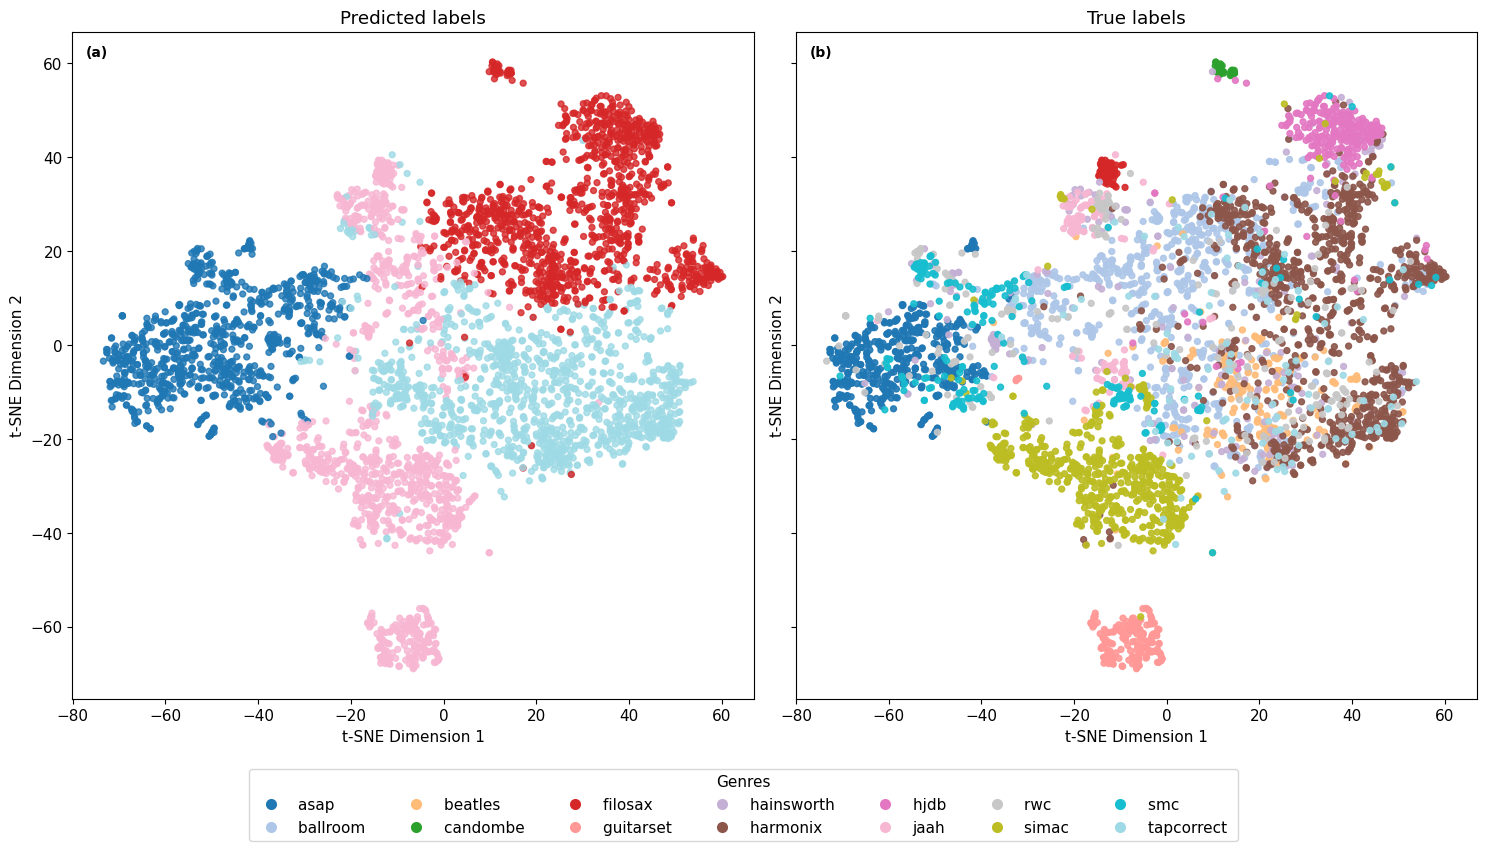

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
from matplotlib import cm
from sklearn.manifold import TSNE
# --- inputs you already have ---
#X_2d: (n,2) t-SNE coords (I keep your precomputed `spectrograms_reduced`)
# aligned_predicted_labels: ints for cluster→genre mapping result
# true_labels_enc: ints for ground-truth labels
# label_names: list of genre names in the same order as encoded labels (0..K-1)
# --------------------------------------------------------------
X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_scaled)
#X_2d = spectrograms_reduced.copy()

# Ensure labels are 0..K-1 and consistent
unique_labels = np.unique(true_labels_enc)
K = len(unique_labels)

# Color map with exactly K discrete colors (stable across panels)
cmap_name = "tab20"
cmap_k = cm.get_cmap(cmap_name, K)

# Build handles for a single shared legend (use true-label counts)
counts = [(true_labels_enc == lab).sum() for lab in unique_labels]
handles = [
    Line2D([0],[0], marker='o', linestyle='', markersize=8,
           markerfacecolor=cmap_k(i), markeredgecolor='none',
           label=f"{label_names[i]} ")
    for i in range(K)
]
matplotlib.rcParams.update({'font.size': 11})
# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True)

# Left: clustered result (use same discrete cmap)
axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                c=predicted_labels, cmap=cmap_k, s=18, alpha=0.8)
axes[0].set_title("Predicted labels")

# Right: true labels
axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                c=true_labels_enc, cmap=cmap_k, s=18, alpha=0.9)
axes[1].set_title("True labels")

# Clean axes
for ax, tag in [(axes[0], "(a)"), (axes[1], "(b)")]:
    #ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.text(0.02, 0.98, tag, transform=ax.transAxes,
            ha="left", va="top", fontsize=10, fontweight="bold")

# One shared legend above both plots, multi-column
leg = fig.legend(handles=handles, loc="upper center", ncol=7,
                 bbox_to_anchor=(0.5, 0), frameon=True, title="Genres")
#leg._legend_box.align = "left"
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")

axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for legend
#plt.savefig("figures/plot_k-means_52.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [131]:
set(predicted_labels)

{0, 1, 2, 3}

In [40]:
import plotly.express as px
import pandas as pd
from sklearn.manifold import TSNE

# Assume you have: 
# - spectrograms_umap (UMAP-reduced features)
# - predicted_labels (cluster labels)
# - file_names (a list with one file name per point)

# Step 1: Reduce dimensions with t-SNE
X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_scaled)
#X_2d = spectrograms_reduced.copy()
file_names = data.files
# Step 2: Create a DataFrame for Plotly
df = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
    'label': predicted_labels,
    'file': spectrograms.keys()
})

# Step 3: Plot interactive scatter
fig = px.scatter(
    df,
    x='x', y='y',
    color=df['label'].astype(str),  # Convert to string for discrete colors
    hover_data=['file'],
    title=f" Clustering {algorithm} with  t-SNE"
)
fig.update_layout(
    autosize = False,
    width = 1000,
    height = 1000
)
#fig.show()
fig.write_html("scatter_plot_aggl.html")
#fig.show(renderer="browser")
